### 1. Load the Data

First, we'll load the `housing.csv` dataset into a pandas DataFrame and display the first few rows to understand its structure.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('housing.csv')

display(df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 2. Data Exploration and Preparation

We'll check for missing values, select relevant features, and define our target variable. For a *simple* linear regression, we'll choose one feature, for example, 'sqft_living' (living area square footage) to predict 'price'.

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


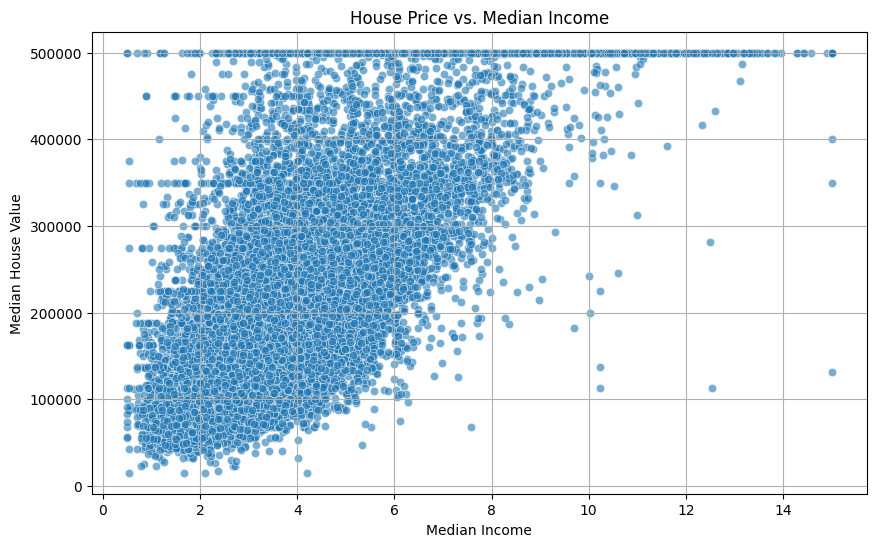

In [13]:
display(df.isnull().sum())

X = df[['median_income']]
y = df['median_house_value']

plt.figure(figsize=(10, 6))
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.6)
plt.title('House Price vs. Median Income')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.grid(True)
plt.show()

### 3. Split the Data

We'll split the data into training and testing sets to evaluate the model's performance on unseen data.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 16512 samples
Test set size: 4128 samples


### 4. Build and Train the Simple Linear Regression Model

We'll initialize a `LinearRegression` model and train it using our training data.

In [15]:
model = LinearRegression()

model.fit(X_train, y_train)

print(f"Model Intercept: {model.intercept_:.2f}")
print(f"Model Coefficient (sqft_living): {model.coef_[0]:.2f}")

Model Intercept: 44459.73
Model Coefficient (sqft_living): 41933.85


### 5. Make Predictions

Now, we'll use the trained model to make predictions on the test set.

In [16]:
y_pred = model.predict(X_test)

predictions_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})
display(predictions_df.head())

,Actual Price,Predicted Price
20046,47700.0,114958.916770
3024,45800.0,150606.882140
15663,500001.0,190393.718444
20484,218600.0,285059.383451
9814,278000.0,200663.318161


### 6. Evaluate the Model

Finally, we'll evaluate the model's performance using metrics like Mean Squared Error (MSE) and R-squared ($R^2$).

Mean Squared Error (MSE): 7091157771.77
Root Mean Squared Error (RMSE): 84209.01
R-squared (R^2): 0.46


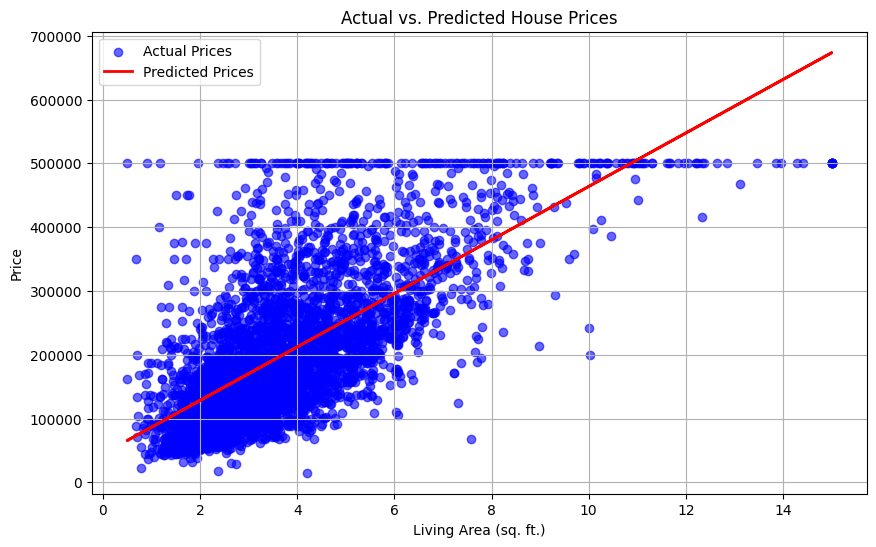

In [17]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R^2): {r2:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Prices', alpha=0.6)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Prices')
plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Living Area (sq. ft.)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()